<h1><font color="#113D68" size=5>Redes neuronales y deep learning</font></h1>



<h1><font color="#113D68" size=6>Actividad Semana 2</font></h1>


<br><br>
<div style="text-align: right">
<font size=3>Daniel González</font><br>
<font size=3>Semana 2: Frameworks de Deep Learning: TensorFlow</font><br>
<font size=3>IEBS</font>
</div>

---


In [2]:
import tensorflow as tf
import numpy as np

# Para mostrar gráficas
import matplotlib.pyplot as plt
%matplotlib inline

# Anaconda fixing problem
# import os
# os.environ['KMP_DUPLICATE_LIB_OK']='True' #Esta no es la solución optima, pero es la más rápida para evitar el error de duplicación de librerías de Anaconda
# En el propio mensaje de error indica que esta no es la mejor solución, puede arreglarse buscando la ubicación del fichero y eliminando la duplicación de librerías.
# Hecho

En esta actividad vamos a seguir familiarizándonos con la herramienta *TensorFlow*, para ello vamos a utilizar un dataset donde tendréis que relizar todos los pasos (cargar datos, crear arquitectura de la red, etc.) vosotros mismos para prácticar con la sintásis de *TensorFlow*. Tendéis ejercicios obligatorio y un ejercicio opcional.

# <font color="#004D7F" size=5>Ejercicio</font>
Usando los datos visto en los ejercicios sobre casa y sus precios realiza los ejercicios que se indican.

La información de los datos podéis verla en este enlace:

https://www.tensorflow.org/api_docs/python/tf/keras/datasets/boston_housing/load_data

## <font color="#004D7F" size=4>Ejercicio 1</font>
Carga los datos como hemos visto en el notebook de los ejercicios donde tengas los conjuntos de train y test:

In [3]:
# Cargamos los datos de Boston Housing

(train_data, train_targets), (test_data, test_targets) = tf.keras.datasets.boston_housing.load_data()

# Exportamos los datos para poder cargarlos en pytorch

import numpy as np

np.savez('boston.npz', train_data=train_data, train_targets=train_targets, test_data=test_data, test_targets=test_targets)



In [1]:
# Cargamos los datos para pytorch
import numpy as np

# Cargamos los datos de Boston Housing
data = np.load('boston.npz')
train_data = data['train_data']
train_targets = data['train_targets']
test_data = data['test_data']
test_targets = data['test_targets']

Explora los tamaños de cada conjunto:

In [4]:
# Comprobamos el shape de los datos
print("train_data shape: ", train_data.shape)
print("train_targets shape: ", train_targets.shape)
print("test_data shape: ", test_data.shape)
print("test_targets shape: ", test_targets.shape)


train_data shape:  (404, 13)
train_targets shape:  (404,)
test_data shape:  (102, 13)
test_targets shape:  (102,)


## <font color="#004D7F" size=4>Ejercicio 2</font>
Crear una red con la siguiente configuración y entrénala:

- **Configuración de la red**:
    - Arquitectura de la red:
        - *1º Capa*: capa de entrada donde indiques la dimensión de los datos.
        - *2º Capa*: capa densa con 8 neuronas y función de activación *relu*.
        - *3º Capa*: capa densa con 8 neuronas y función de activación *relu*.
        - *4º Capa*: capa de salida con una neurona sin función de activación.
    - Tipo de entrenamiento:
        - *Epochs*: 100
        - *Optimizador*: *adam*
        - *Learning Rate*: 0.001
        - *Función de error*: error cuadrático medio (*mean_squared_error*)

In [10]:
# Importamos las capas que vamos a necesitar
from tensorflow.keras.layers import Dense, InputLayer

# Importamos las métricas que vamos a utilizar
from tensorflow.keras.metrics import MeanAbsoluteError, MeanSquaredError

# Creamos la arquitectura del modelo

model = tf.keras.Sequential()

model.add(InputLayer(input_shape=(train_data.shape[1],)))
model.add(Dense(8, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation=None))

# Definimos el optimizador
opt = tf.keras.optimizers.Adam(learning_rate=0.001)

# Compilamos el modelo
model.compile(optimizer= opt, loss='mse', metrics=['mae'])

print(model.summary())


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 8)                 112       
                                                                 
 dense_1 (Dense)             (None, 8)                 72        
                                                                 
 dense_2 (Dense)             (None, 1)                 9         
                                                                 
Total params: 193
Trainable params: 193
Non-trainable params: 0
_________________________________________________________________
None


In [11]:
history = model.fit(train_data, train_targets, epochs=100, validation_split=0.2, batch_size=32, verbose=1)

Epoch 1/100
11/11 [==============================] - 1s 15ms/step - loss: 2222.6499 - mae: 41.9005 - val_loss: 1084.9606 - val_mae: 28.8022
Epoch 2/100
11/11 [==============================] - 0s 2ms/step - loss: 852.1455 - mae: 24.1325 - val_loss: 396.5428 - val_mae: 16.6392
Epoch 3/100
11/11 [==============================] - 0s 2ms/step - loss: 345.9504 - mae: 14.5898 - val_loss: 239.3678 - val_mae: 12.7188
Epoch 4/100
11/11 [==============================] - 0s 2ms/step - loss: 244.0269 - mae: 12.2259 - val_loss: 220.5260 - val_mae: 12.0434
Epoch 5/100
11/11 [==============================] - 0s 2ms/step - loss: 219.6369 - mae: 11.6748 - val_loss: 206.7370 - val_mae: 11.4690
Epoch 6/100
11/11 [==============================] - 0s 2ms/step - loss: 192.9017 - mae: 10.7583 - val_loss: 179.6806 - val_mae: 10.5070
Epoch 7/100
11/11 [==============================] - 0s 2ms/step - loss: 164.2772 - mae: 9.6270 - val_loss: 156.3679 - val_mae: 9.6283
Epoch 8/100
11/11 [=====================

Evalúa el modelo usando la función *evaluate* para el conjunto de test:

4/4 [==============================] - 0s 837us/step - loss: 51.2494 - mae: 5.1856
Resultados del modelo
MSE:  51.24944305419922
MAE:  5.185574531555176
Gráfica de evolución del entrenamiento


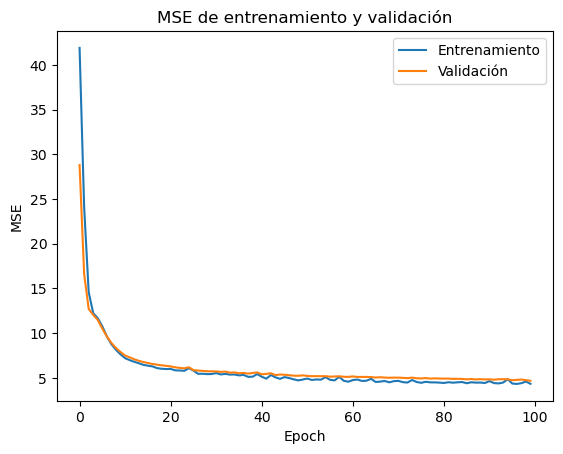

4/4 [==============================] - 0s 838us/step - loss: 51.2494 - mae: 5.1856


In [12]:
# Guardamos todos los resultados
resultados = []

# Vamos a evaluar el modelo
resultado = model.evaluate(test_data, test_targets, verbose=1)
print('Resultados del modelo')
print('MSE: ', resultado[0])
print('MAE: ', resultado[1])

resultados.append(resultado)

# Representamos los resultados en una gráfica
print('Gráfica de evolución del entrenamiento')
plt.plot(history.history['mae'])
plt.plot(history.history['val_mae'])
plt.title('MSE de entrenamiento y validación')
plt.ylabel('MSE')
plt.xlabel('Epoch')
plt.legend(['Entrenamiento', 'Validación'], loc='upper right')
plt.show()


# Vamos a evaluar el modelo
resultado = model.evaluate(test_data, test_targets, verbose=1)


## <font color="#004D7F" size=4>Ejercicio 3</font>
Crear una red con la siguiente configuración y entrénala:

- **Configuración de la red**:
    - Arquitectura de la red:
        - *1º Capa*: capa de entrada donde indiques la dimensión de los datos.
        - *2º Capa*: capa densa con 16 neuronas y función de activación *relu*.
        - *3º Capa*: capa densa con 16 neuronas y función de activación *relu*.
        - *4º Capa*: capa densa con 32 neuronas y función de activación *relu*.
        - *4º Capa*: capa de salida con una neurona sin función de activación.   
    - Tipo de entrenamiento:
        - *Epochs*: 300
        - *Optimizador*: *adam*
        - *Learning Rate*: 0.0001
        - *Función de error*: error cuadrático medio (*mean_squared_error*)

In [13]:
# Establecemos la arquitectura del modelo

model2 = tf.keras.Sequential()
model2.add(InputLayer(input_shape=(train_data.shape[1],)))
model2.add(Dense(16, activation='relu'))
model2.add(Dense(16, activation='relu'))
model2.add(Dense(32, activation='relu'))
model2.add(Dense(1, activation=None))

print(model2.summary())

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 16)                224       
                                                                 
 dense_4 (Dense)             (None, 16)                272       
                                                                 
 dense_5 (Dense)             (None, 32)                544       
                                                                 
 dense_6 (Dense)             (None, 1)                 33        
                                                                 
Total params: 1,073
Trainable params: 1,073
Non-trainable params: 0
_________________________________________________________________
None


In [14]:
# Definimos el optimizador
opt = tf.keras.optimizers.Adam(learning_rate=0.0001)

# Entrenamos el modelo
model2.compile(optimizer='adam', loss='mse', metrics=['mae'])
history2 = model2.fit(train_data, train_targets, validation_split=0.2, epochs=300, batch_size=32, verbose=1)

Epoch 1/300
11/11 [==============================] - 0s 12ms/step - loss: 1796.4988 - mae: 38.1893 - val_loss: 401.0418 - val_mae: 16.4731
Epoch 2/300
11/11 [==============================] - 0s 2ms/step - loss: 462.5064 - mae: 14.9781 - val_loss: 243.8951 - val_mae: 11.2317
Epoch 3/300
11/11 [==============================] - 0s 2ms/step - loss: 208.1348 - mae: 9.7730 - val_loss: 131.7505 - val_mae: 8.0220
Epoch 4/300
11/11 [==============================] - 0s 2ms/step - loss: 102.6572 - mae: 7.0861 - val_loss: 75.8638 - val_mae: 5.7904
Epoch 5/300
11/11 [==============================] - 0s 2ms/step - loss: 75.7155 - mae: 6.6684 - val_loss: 70.6642 - val_mae: 5.9678
Epoch 6/300
11/11 [==============================] - 0s 2ms/step - loss: 68.2699 - mae: 5.9063 - val_loss: 77.4680 - val_mae: 5.7530
Epoch 7/300
11/11 [==============================] - 0s 2ms/step - loss: 67.6732 - mae: 5.9006 - val_loss: 69.2629 - val_mae: 5.8551
Epoch 8/300
11/11 [==============================] - 0s 

Evalúa el modelo usando la función *evaluate* para el conjunto de test:

4/4 [==============================] - 0s 1ms/step - loss: 38.5416 - mae: 4.4540
Resultados del modelo
MSE:  38.541629791259766
MAE:  4.453950881958008
Gráfica de evolución del entrenamiento


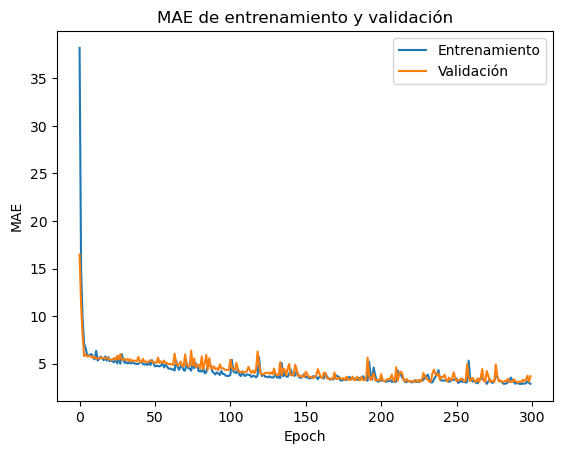

In [15]:
# Vamos a evaluar el modelo
resultado2 = model2.evaluate(test_data, test_targets, verbose=1)
print('Resultados del modelo')
print('MSE: ', resultado2[0])
print('MAE: ', resultado2[1])

resultados.append(resultado2)

# Representamos los resultados en una gráfica
print('Gráfica de evolución del entrenamiento')
plt.plot(history2.history['mae'])
plt.plot(history2.history['val_mae'])
plt.title('MAE de entrenamiento y validación')
plt.ylabel('MAE')
plt.xlabel('Epoch')
plt.legend(['Entrenamiento', 'Validación'], loc='upper right')
plt.show()

## <font color="#004D7F" size=4>Ejercicio 4</font>
Crear una red con la siguiente configuración y entrénala:

- **Configuración de la red**:
    - Arquitectura de la red:
        - *1º Capa*: capa de entrada donde indiques la dimensión de los datos.
        - *2º Capa*: capa densa con 32 neuronas y función de activación *relu*.
        - *3º Capa*: capa densa con 64 neuronas y función de activación *relu*.
        - *4º Capa*: capa densa con 128 neuronas y función de activación *relu*.
        - *4º Capa*: capa de salida con una neurona sin función de activación.   
    - Tipo de entrenamiento:
        - *Epochs*: 2OO
        - *Optimizador*: *adam*
        - *Learning Rate*: 0.001
        - *Función de error*: error cuadrático medio (*mean_squared_error*)

In [16]:
import torch

# Establecemos la arquitectura del modelo

import torch.nn as nn

# Definimos la arquitectura del modelo
class Model3(nn.Module):
    def __init__(self, input_dim):
        super(Model3, self).__init__()
        self.fc1 = nn.Linear(input_dim, 32)
        self.fc2 = nn.Linear(32, 64)
        self.fc3 = nn.Linear(64, 128)
        self.fc4 = nn.Linear(128, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)
        return x

# Creamos una instancia del modelo
input_dim = train_data.shape[1]
model3 = Model3(input_dim)
print(model3)


Model3(
  (fc1): Linear(in_features=13, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=128, bias=True)
  (fc4): Linear(in_features=128, out_features=1, bias=True)
  (relu): ReLU()
)


In [17]:
# Definimos la función de pérdida y el optimizador
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model3.parameters(), lr=0.001)

# Convertimos los datos de entrenamiento a tensores y los movemos al dispositivo
train_data_tensor = torch.tensor(train_data, dtype=torch.float32).to(device)
train_targets_tensor = torch.tensor(train_targets, dtype=torch.float32).to(device)

# Entrenamos el modelo
epochs = 300
batch_size = 32
history3 = {'loss': [], 'val_loss': []}

for epoch in range(epochs):
    model3.train()
    epoch_loss = 0.0

    # Dividimos los datos en lotes
    for i in range(0, len(train_data_tensor), batch_size):
        batch_data = train_data_tensor[i:i+batch_size]
        batch_targets = train_targets_tensor[i:i+batch_size]

        # Forward pass
        outputs = model3(batch_data)
        loss = criterion(outputs.squeeze(), batch_targets)

        # Backward pass y optimización
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    # Guardamos la pérdida de entrenamiento
    history3['loss'].append(epoch_loss / len(train_data_tensor))

    # Validación
    model3.eval()
    with torch.no_grad():
        val_outputs = model3(train_data_tensor)
        val_loss = criterion(val_outputs.squeeze(), train_targets_tensor)
        history3['val_loss'].append(val_loss.item())

    # Mostramos el progreso
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {history3['loss'][-1]:.4f}, Val Loss: {history3['val_loss'][-1]:.4f}")

Epoch [10/300], Loss: 1.8732, Val Loss: 57.1389
Epoch [20/300], Loss: 1.6171, Val Loss: 53.3663
Epoch [30/300], Loss: 1.3817, Val Loss: 49.1260
Epoch [40/300], Loss: 1.1135, Val Loss: 39.1467
Epoch [50/300], Loss: 0.8692, Val Loss: 27.7565
Epoch [60/300], Loss: 0.6615, Val Loss: 21.8114
Epoch [70/300], Loss: 0.5473, Val Loss: 17.7171
Epoch [80/300], Loss: 0.4922, Val Loss: 15.6611
Epoch [90/300], Loss: 0.4603, Val Loss: 14.7235
Epoch [100/300], Loss: 0.4310, Val Loss: 13.1218
Epoch [110/300], Loss: 0.4171, Val Loss: 12.4967
Epoch [120/300], Loss: 0.3912, Val Loss: 12.3254
Epoch [130/300], Loss: 0.3761, Val Loss: 11.6950
Epoch [140/300], Loss: 0.3670, Val Loss: 11.4000
Epoch [150/300], Loss: 0.3521, Val Loss: 10.5739
Epoch [160/300], Loss: 0.3447, Val Loss: 10.3295
Epoch [170/300], Loss: 0.3380, Val Loss: 9.9311
Epoch [180/300], Loss: 0.3352, Val Loss: 10.0639
Epoch [190/300], Loss: 0.3278, Val Loss: 9.3837
Epoch [200/300], Loss: 0.3081, Val Loss: 9.2139
Epoch [210/300], Loss: 0.2951, V

Evalúa el modelo usando la función *evaluate* para el conjunto de test:

Model Results
MSE:  24.914169311523438
MAE:  3.380772352218628
Training Evolution Graph


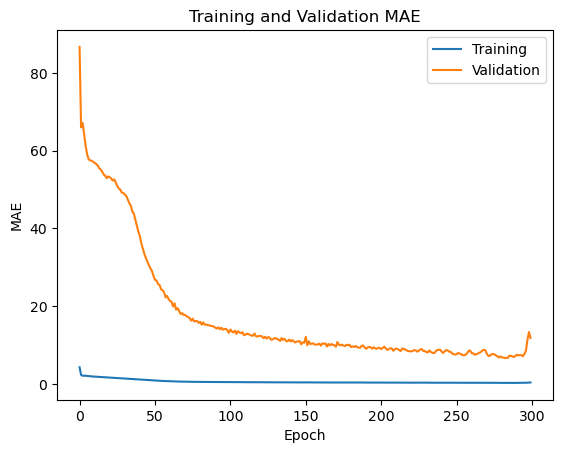

In [20]:
# Define the device if not already defined
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Convert test data to tensors and move them to the device
test_data_tensor = torch.tensor(test_data, dtype=torch.float32).to(device)
test_targets_tensor = torch.tensor(test_targets, dtype=torch.float32).to(device)

# Evaluate the model
model3.eval()
with torch.no_grad():
    outputs = model3(test_data_tensor)
    loss = criterion(outputs.squeeze(), test_targets_tensor)
    resultado3 = [loss.item(), torch.mean(torch.abs(outputs.squeeze() - test_targets_tensor)).item()]

# Display the results
print('Model Results')
print('MSE: ', resultado3[0])
print('MAE: ', resultado3[1])

resultados.append(resultado3)

# Plot the results
print('Training Evolution Graph')
plt.plot(history3['loss'])
plt.plot(history3['val_loss'])
plt.title('Training and Validation MAE')
plt.ylabel('MAE')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.show()

## <font color="#004D7F" size=4>Ejercicio 5</font>
Compara los resultados obtenidos en cada uno de los modelos entrenados y quédate con el mejor. **Justifica tu respuesta**.

El resultado no tiene porqué ser el mismo ya que los entrenamientos son aleatorios, pero un posible resultado podría ser este:

In [21]:
m = 0
for res in resultados:
    m+=1
    print('Modelo', m)
    print('MAE: ', res[1])
    print('MSE: ', res[0])
    print('-----------------------------------------')


Modelo 1
MAE:  5.185574531555176
MSE:  51.24944305419922
-----------------------------------------
Modelo 2
MAE:  4.453950881958008
MSE:  38.541629791259766
-----------------------------------------
Modelo 3
MAE:  3.380772352218628
MSE:  24.914169311523438
-----------------------------------------
Modelo 4
MAE:  3.380772352218628
MSE:  24.914169311523438
-----------------------------------------
Modelo 5
MAE:  3.380772352218628
MSE:  24.914169311523438
-----------------------------------------


In [36]:
print(np.sqrt(resultados[1][0]))
print(np.sqrt(resultados[2][0])) 

5.42517341301449
5.500455664052482


Atendiendo a las dos métricas evaluadas para cada una de las respectivas redes neuronales, podemos decir que los mejores modelos son los dos últimos, obteniendo unos resultados de ambas métricas muy parejos. Si bien es cierto que debido a la superior velocidad de aprendizaje, el tercer modelo presenta mayor variabilidad a lo largo de las épocas, mientras que el segundo es más estable, aunque también cabe señalar que el tercero se entrena en menor tiempo. Sin embargo, dada la sencillez de los datos, es preferible el modelo con un resultado más estable a lo largo de su entrenamiento, dado que será menos probable que haya dado con un mínimo local. Por lo tanto, de tener que elegir un único modelo, me quedaría con el segundo.

Además guarda el mejor modelo en formato *.h5* usando la función `save`:

In [37]:
# Guardamos el segundo modelo
model2.save('modelo2.h5')

## <font color="#004D7F" size=4>Ejercicio 6 (Opcional)</font>
Carga el mejor modelo que has guardado en el ejercicio anterior usando la función `load_model` y realizar predicciones usando la función `predict`.

Para realizar las predicciones usa 10 datos cualquier del conjunto de test:

In [49]:

# Cargamos el modelo guardado
model_ld = tf.keras.models.load_model('modelo2.h5')

# Realizamos predicciones de nuevos datos
x_new = np.random.rand(10, train_data.shape[1])
y_pred = model_ld.predict(x_new)

print('Predicción de nuevos datos: ', y_pred)

Predicción de nuevos datos:  [[0.3843294]
 [1.3237385]
 [1.2367032]
 [1.413594 ]
 [1.7150954]
 [2.792757 ]
 [2.2441602]
 [1.0939713]
 [2.6992464]
 [1.7149708]]
